# Before your start:

    Read the README.md file
    Comment as much as you can and use the resources (README.md file)
    Happy learning!

*Notes:* 

- Solve the questions with python.

- Round the final answer to three decimal places.

In [2]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import math

## Bernoulli's Distribution

In a basket containing 100 fruits, there are 60 apples and 40 oranges. 

A fruit is picked randomly from the basket. 

1. **What is the probability that the fruit is apple?**
1. **What is the probability that it is an orange?**

In [3]:
"""
Calculate:
p = probability that the fruit is an apple 
q = probability that the fruit is an orange
"""

# Import the fractions module for exact probability representations
from fractions import Fraction

# Define the number of fruits
total_fruits = 100
apples = 60
oranges = 40

# Calculate probability of apple (p)
p_apple = Fraction(apples, total_fruits)

# Calculate probability of orange (q) - or use complement: 1 - p_apple
q_orange = Fraction(oranges, total_fruits)  # Direct calculation
# Alternative: q_orange = 1 - p_apple  # This would also work

# Convert to decimals for display
p_apple_decimal = float(p_apple)
q_orange_decimal = float(q_orange)

# Print the results
print("Bernoulli's Distribution: Fruit Picking Probabilities\n")
print(f"1. P(fruit is apple) = p = {p_apple} ≈ {p_apple_decimal:.2f}")
print(f"2. P(fruit is orange) = q = {q_orange} ≈ {q_orange_decimal:.2f}")
print(f"Verification: p + q = {p_apple + q_orange} (should be 1)")

Bernoulli's Distribution: Fruit Picking Probabilities

1. P(fruit is apple) = p = 3/5 ≈ 0.60
2. P(fruit is orange) = q = 2/5 ≈ 0.40
Verification: p + q = 1 (should be 1)


Now we take a random sample of 20 fruits from the basket. After each fruit is taken, a new fruit of the same type is replaced in the basket. Therefore, every time we are taking 1 fruit from 100 fruits. 

1. **What is the probability that the first 5 fruits are all apples?**

1. **What is the probability that the first 5 fruits are all apples and the next 15 fruits are all oranges?**

You can include the `p` and `q` probabilities you previous calculated in your solution.

In [4]:
# Import the fractions module for exact probability representations
from fractions import Fraction

# Reuse probabilities from previous calculation
p_apple = Fraction(60, 100)  # p = 60/100 = 3/5
q_orange = Fraction(40, 100)  # q = 40/100 = 2/5

# Probability 1: First 5 fruits are all apples (independent draws with replacement)
prob_all_5_apples = p_apple ** 5

# Probability 2: First 5 all apples AND next 15 all oranges
prob_5_apples_and_15_oranges = (p_apple ** 5) * (q_orange ** 15)

# Convert to decimals for display
prob1_decimal = float(prob_all_5_apples)
prob2_decimal = float(prob_5_apples_and_15_oranges)

# Print the results
print("Bernoulli's Distribution: Sampling with Replacement\n")
print(f"1. P(first 5 are all apples) = p^5 = {prob_all_5_apples} ≈ {prob1_decimal:.5f}")
print(f"2. P(first 5 apples AND next 15 oranges) = p^5 × q^15 = {prob_5_apples_and_15_oranges} ≈ {prob2_decimal:.2e}")



Bernoulli's Distribution: Sampling with Replacement

1. P(first 5 are all apples) = p^5 = 243/3125 ≈ 0.07776
2. P(first 5 apples AND next 15 oranges) = p^5 × q^15 = 7962624/95367431640625 ≈ 8.35e-08


## Binomial Distribution

Similar to the above problem, this time again we randomly sample 20 fruits.

**What is the probability that this time the sample contains 5 apples and 15 oranges?**

Please note that this time the order of the fruits being picked does not matter.

In [5]:
# your solution here

# Import necessary modules for combinations and fractions
from math import comb
from fractions import Fraction

# Define parameters
n = 20  # Number of trials (fruits sampled)
k_apples = 5  # Number of successes (apples)
p_apple = Fraction(60, 100)  # p = 60/100 = 3/5
q_orange = Fraction(40, 100)  # q = 40/100 = 2/5

# Compute binomial coefficient C(n, k)
binomial_coeff = comb(n, k_apples)

# Compute probability: C(n, k) * p^k * q^(n-k)
prob = binomial_coeff * (p_apple ** k_apples) * (q_orange ** (n - k_apples))

# Convert to decimal for display
prob_decimal = float(prob)

# Print the results
print("Binomial Distribution: Probability of 5 Apples and 15 Oranges in 20 Draws\n")
print(f"P(X=5) = C(20,5) × (0.6)^5 × (0.4)^15 = {prob} ≈ {prob_decimal:.6f}")
print(f"Binomial coefficient C(20,5) = {binomial_coeff}")

Binomial Distribution: Probability of 5 Apples and 15 Oranges in 20 Draws

P(X=5) = C(20,5) × (0.6)^5 × (0.4)^15 = 123452522496/95367431640625 ≈ 0.001294
Binomial coefficient C(20,5) = 15504


In the lesson we also discussed CDF (cumulative distribution function). In the context of the above problem, **what is the probability that less than 5 fruits picked are apples?**

Write the formula and calculate the probability below.

In [6]:
# your code here

# Import necessary modules for combinations and fractions
from math import comb
from fractions import Fraction

# Define parameters
n = 20  # Number of trials
p_apple = Fraction(60, 100)  # p = 3/5
q_orange = Fraction(40, 100)  # q = 2/5

# Function to compute binomial PMF: C(n,k) * p^k * q^(n-k)
def binom_pmf(k, n, p, q):
    return comb(n, k) * (p ** k) * (q ** (n - k))

# Compute CDF P(X <= 4) = sum_{k=0 to 4} P(X=k)
cdf_4 = sum(binom_pmf(k, n, p_apple, q_orange) for k in range(5))

# Convert to decimal
cdf_decimal = float(cdf_4)

# Print individual probabilities and CDF
print("Binomial CDF: P(X < 5) = P(X ≤ 4) in 20 Draws\n")
for k in range(5):
    pmf_k = binom_pmf(k, n, p_apple, q_orange)
    pmf_decimal = float(pmf_k)
    print(f"P(X={k}) = {pmf_k} ≈ {pmf_decimal:.6f}")

print(f"\nCDF P(X ≤ 4) = {cdf_4} ≈ {cdf_decimal:.6f}")

Binomial CDF: P(X < 5) = P(X ≤ 4) in 20 Draws

P(X=0) = 1048576/95367431640625 ≈ 0.000000
P(X=1) = 6291456/19073486328125 ≈ 0.000000
P(X=2) = 89653248/19073486328125 ≈ 0.000005
P(X=3) = 806879232/19073486328125 ≈ 0.000042
P(X=4) = 5143855104/19073486328125 ≈ 0.000270

CDF P(X ≤ 4) = 30234443776/95367431640625 ≈ 0.000317


<!-- **Plot the PDF (probability distributiom function) for the above binomial distribution.** -->

**Plot the Probability Mass Function (PMF) for the above binomial distribution.**

*Hint: The range of x in a binomial distribution is from `0` to `n`.*

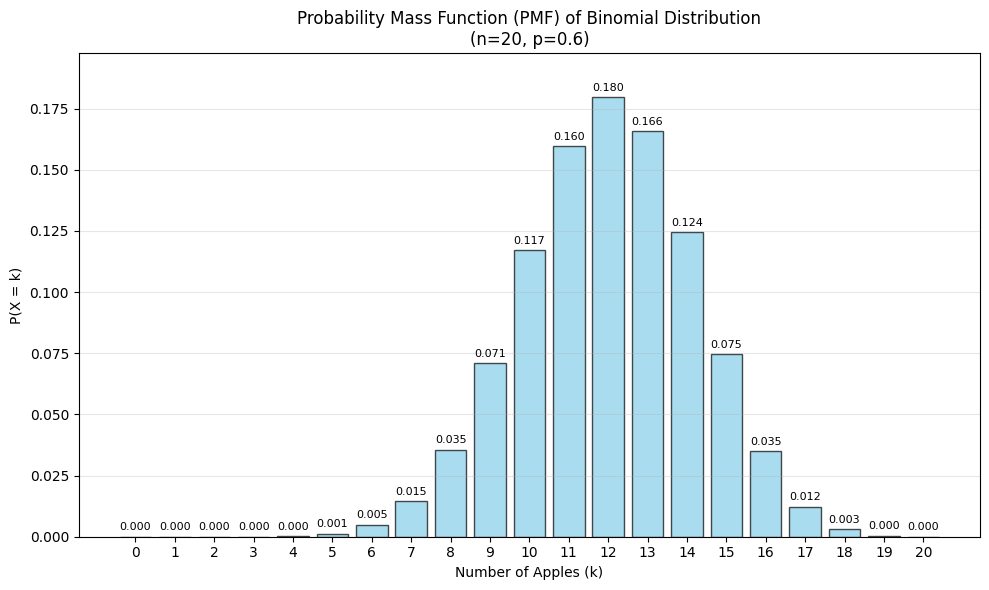

In [7]:
# your code here
# Please label the axes and give a title to the plot 

# Import necessary modules for combinations, arrays, and plotting
from math import comb
import numpy as np
import matplotlib.pyplot as plt

# Define parameters
n = 20  # Number of trials
p = 0.6  # Probability of success (apple)

# Compute PMF values for k = 0 to n
k_values = np.arange(0, n + 1)  # Array [0, 1, ..., 20]
pmf_values = np.array([comb(n, int(k)) * (p ** k) * ((1 - p) ** (n - k)) for k in k_values])

# Create the plot: Bar chart for PMF
plt.figure(figsize=(10, 6))
plt.bar(k_values, pmf_values, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Probability Mass Function (PMF) of Binomial Distribution\n(n=20, p=0.6)')
plt.xlabel('Number of Apples (k)')
plt.ylabel('P(X = k)')
plt.xticks(k_values)  # Show all integer ticks on x-axis
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, max(pmf_values) * 1.1)  # Add some headroom on y-axis

# Add value labels on bars (optional, for readability)
for i, v in enumerate(pmf_values):
    plt.text(i, v + max(pmf_values)*0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('binomial_pmf.png')  # Save the plot to file
plt.show()  # Display the plot if in interactive mode (e.g., Jupyter)

## Poisson Distribution

In this challenge you are required to use the Math library in python to solve the problems.

In the UEFA champions league tournament, the average number of goals scored in a match is 2.3. 

**What is the probability that the number of goals scored in a match is 5?**

*Hint: Use the exp() in the math library*

And to calculate the factorial, you can use the following code:

```python
import math
math.factorial(n) # n is the number you want to find the factorial of
```

In [8]:
# your code here 

# Import the math library as required
import math

# Define the Poisson parameters
lambda_val = 2.3  # Average number of goals (λ)
k = 5             # Number of goals to find probability for

# Compute Poisson PMF: P(X = k) = (e^{-λ} * λ^k) / k!
# Use math.exp(-lambda_val) for e^{-λ}
# Use math.factorial(k) for k!
numerator = math.exp(-lambda_val) * (lambda_val ** k)
denominator = math.factorial(k)
prob = numerator / denominator

# Print the result
print("Poisson Distribution: Probability of Exactly 5 Goals\n")
print(f"P(X = 5) = {prob:.4f} (or {prob:.2%})")

Poisson Distribution: Probability of Exactly 5 Goals

P(X = 5) = 0.0538 (or 5.38%)


**Draw a poisson probability distribution plot for the number of goals to be between 0 to 10.**

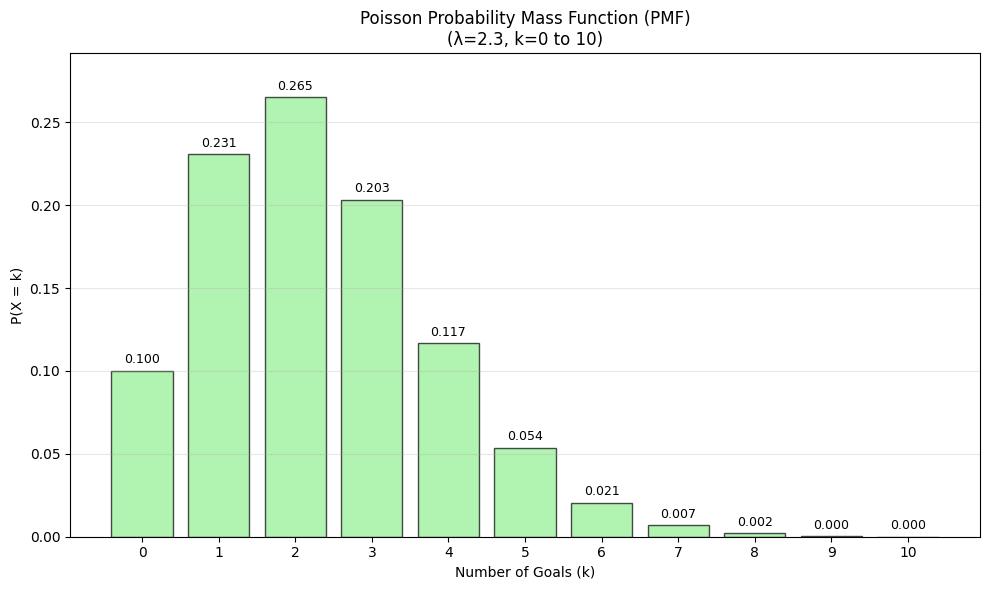

In [9]:
# your code here
# Please label the axes and give a title to the plot 

# Import necessary modules
import math
import matplotlib.pyplot as plt
import numpy as np  # For arange, but optional here

# Define Poisson parameters
lambda_val = 2.3  # Average goals (λ)
max_k = 10        # Plot up to k=10

# Compute PMF values for k=0 to max_k
k_values = list(range(max_k + 1))
pmf_values = []
for k in k_values:
    # P(X=k) = (exp(-λ) * λ^k) / k!
    pmf = (math.exp(-lambda_val) * (lambda_val ** k)) / math.factorial(k)
    pmf_values.append(pmf)

# Create the bar plot
plt.figure(figsize=(10, 6))
plt.bar(k_values, pmf_values, color='lightgreen', edgecolor='black', alpha=0.7)
plt.title('Poisson Probability Mass Function (PMF)\n(λ=2.3, k=0 to 10)')
plt.xlabel('Number of Goals (k)')
plt.ylabel('P(X = k)')
plt.xticks(k_values)
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, max(pmf_values) * 1.1)

# Add value labels on bars
for i, v in enumerate(pmf_values):
    plt.text(i, v + max(pmf_values)*0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('poisson_pmf.png')  # Save to file
plt.show()  # Display if interactive